# CIFAR-10 classification with Transfer Learning using a pretrained ResNet18

Training is performed in two steps:
- Train final classification (FC) layer
- Fine-tune the entire network

Final Test Accuracy = *94.85%*

## Transform functions, datasets and dataloaders:

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision
import torch.optim as optim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# variables
batch_size = 32
learning_rate_1 = 0.001
learning_rate_2 = 0.00001
weight_decay = 0.0001

FC_epochs = 2
fine_tuning_epochs = 5

# the transform functions
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225))])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225))
    ])

# the datasets
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=test_transform)

# dataloaders
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 47.0MB/s]


## Model Setup

In [5]:
# resnet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# replace final classificaion layers
model.fc = nn.Linear(model.fc.in_features, 10)

# use cuda (if available)
model = model.to(DEVICE)

# the loss function
loss_fn = nn.CrossEntropyLoss()

# store metrics for graphs
train_losses = []
train_accuracies = []

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


## step 1 training FC layer

In [6]:
# Optimizer for FC training
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=learning_rate_1)

print("\nTraining FC Layer\n")

# train mode
model.train()

# training loop
for epoch in range(FC_epochs):

    total = 0
    correct = 0
    epoch_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct +=  (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{FC_epochs}")
    print(f"Loss: {epoch_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100*correct/total:.2f}%")
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)


Training FC Layer

Epoch 1/2
Loss: 0.8008
Train Accuracy: 73.67%
Epoch 2/2
Loss: 0.6327
Train Accuracy: 78.37%


## step 2 fine tuning

In [7]:
# unfreeze the layers
for param in model.parameters():
    param.requires_grad = True

# weight decay optimizer for fine Tuning
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate_2,
    weight_decay=weight_decay
)

print("\nFine Tuning\n")

# train mode
model.train()

# train loop
for epoch in range(fine_tuning_epochs):

    total = 0
    correct = 0
    epoch_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{fine_tuning_epochs}")
    print(f"Loss: {epoch_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100*correct/total:.2f}%")
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)


Fine Tuning

Epoch 1/5
Loss: 0.3576
Train Accuracy: 87.67%
Epoch 2/5
Loss: 0.2127
Train Accuracy: 92.70%
Epoch 3/5
Loss: 0.1602
Train Accuracy: 94.48%
Epoch 4/5
Loss: 0.1255
Train Accuracy: 95.75%
Epoch 5/5
Loss: 0.0988
Train Accuracy: 96.77%


## evaluating the model

In [8]:
# evaluate mode
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 94.85%


## Visualizations

Below are train-loss and train-accuracy graphs.

The train-loss graph shows how loss decreases with epochs.
The train-accuracy graph shows how accuracy increases with epochs.

I also added a dashed line to mark where the model changes from training only the classification layer to fine-tuning the entire network.

### Train Loss graph:

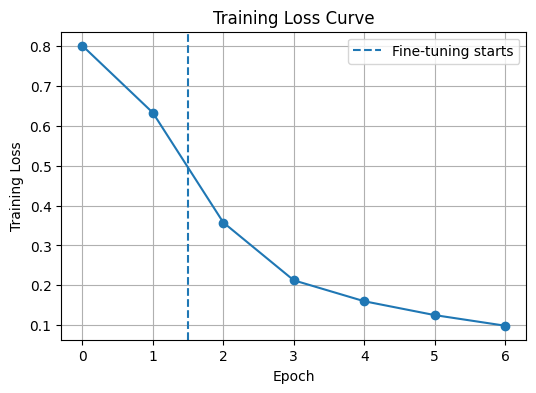

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")

plt.axvline(x=FC_epochs-0.5, linestyle="--", label="Fine-tuning starts")
plt.legend()

plt.grid(True)
plt.show()

### Train accuracy graph:

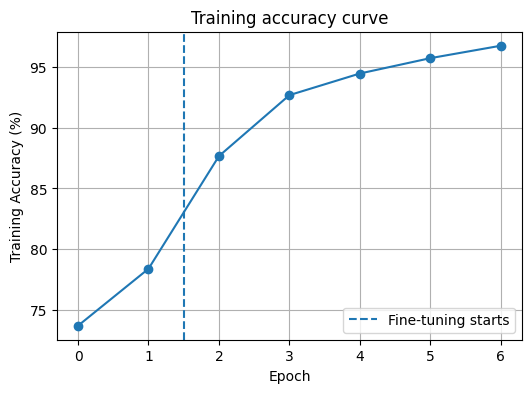

In [11]:
plt.figure(figsize=(6,4))
plt.plot(train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training accuracy curve")

plt.axvline(x=FC_epochs-0.5, linestyle="--", label="Fine-tuning starts")
plt.legend()
plt.grid(True)
plt.show()